# Business Question 1

How serious is customer churn?

Before identifying the factors influencing churn, we first need to understand the overall magnitude of the problem.

This analysis answers:

- How many customers does the company have?
- How many customers have churned?
- What is the overall churn rate?
- Is churn a significant business concern?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

In [3]:
df = pd.read_csv("../data/cleaned/Telco_customer_churn_clean.csv")

df.head()

,CustomerID,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 7043
Columns : 30


In [ ]:
total_customers = len(df)

churned_customers = df["Churn Value"].sum()

active_customers = total_customers - churned_customers

churn_rate = (churned_customers / total_customers) * 100

print(f"Total Customers   : {total_customers}")
print(f"Active Customers  : {active_customers}")
print(f"Churned Customers : {churned_customers}")
print(f"Churn Rate        : {churn_rate:.2f}%")

Total Customers   : 7043
Active Customers  : 5174
Churned Customers : 1869
Churn Rate        : 26.54%


In [ ]:
print("=" * 40)
print("CUSTOMER CHURN OVERVIEW")
print("=" * 40)

print(f"Total Customers   : {total_customers:,}")
print(f"Active Customers  : {active_customers:,}")
print(f"Churned Customers : {churned_customers:,}")
print(f"Churn Rate        : {churn_rate:.2f}%")

CUSTOMER CHURN OVERVIEW
Total Customers   : 7,043
Active Customers  : 5,174
Churned Customers : 1,869
Churn Rate        : 26.54%


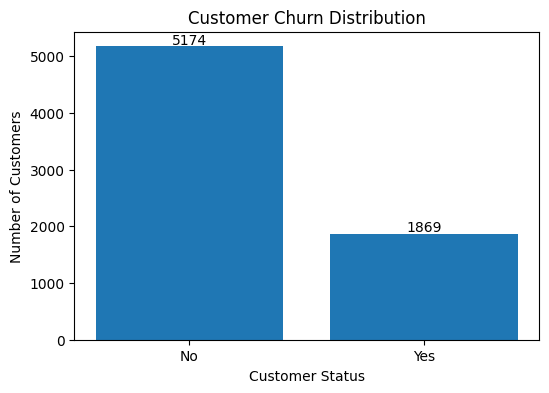

In [ ]:
churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 40, str(value), ha="center")

plt.show()

In [ ]:
churn_percentage = (
    df["Churn Label"]
      .value_counts(normalize=True)
      * 100
)

churn_percentage

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Business Recommendation

### Findings

- The company currently serves **7,043 customers**.
- Approximately **27%** of customers have churned.
- Nearly one out of every four customers is leaving the company.

### Recommendation

The churn rate is sufficiently high to justify a detailed investigation into the underlying causes. The next phase of the analysis will identify which customer segments contribute most to customer attrition, enabling the business to prioritize targeted retention strategies.

# Business Question 2

Which customer segments experience the highest churn?

Understanding the demographic characteristics of churned customers helps identify high-risk customer groups and supports the development of targeted retention strategies.

This analysis answers:

- Does gender influence churn?
- Do senior citizens churn more frequently?
- Does having a partner reduce churn?
- Do customers with dependents churn less?

## Analyze

### Does Senior Citizen status influence customer churn?

Senior citizens often have different service expectations and support requirements compared to younger customers.

This analysis aims to determine whether senior citizens experience higher churn rates than non-senior customers.

In [ ]:
senior_distribution = (
    df["Senior Citizen"]
    .value_counts()
    .rename_axis("Senior Citizen")
    .reset_index(name="Total Customers")
)

senior_distribution

,Senior Citizen,Total Customers
0,No,5901
1,Yes,1142


In [ ]:
senior_churn = pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"]
)

senior_churn

Churn Label,No,Yes
Senior Citizen,,
No,4508,1393
Yes,666,476


In [ ]:
senior_churn_rate = (
    pd.crosstab(
        df["Senior Citizen"],
        df["Churn Label"],
        normalize="index"
    ) * 100
).round(2)

senior_churn_rate

Churn Label,No,Yes
Senior Citizen,,
No,76.39,23.61
Yes,58.32,41.68


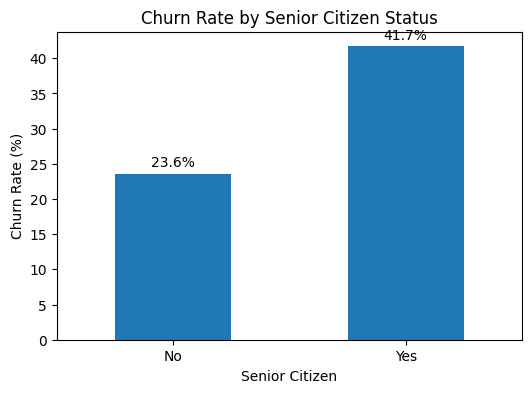

In [ ]:
senior_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

for i, value in enumerate(senior_churn_rate["Yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

In [ ]:
highest_group = senior_churn_rate["Yes"].idxmax()
highest_rate = senior_churn_rate["Yes"].max()

print(f"Highest Churn Group : {highest_group}")
print(f"Churn Rate          : {highest_rate:.2f}%")

Highest Churn Group : Yes
Churn Rate          : 41.68%


In [ ]:
difference = (
    senior_churn_rate.loc["Yes", "Yes"]
    - senior_churn_rate.loc["No", "Yes"]
)

print(f"Difference in Churn Rate : {difference:.2f}%")

Difference in Churn Rate : 18.07%


## Business Insight

Although senior citizens represent a relatively small portion of the customer base, they exhibit a substantially higher churn rate than non-senior customers.

The analysis shows that **41.68%** of senior citizens have churned compared to **23.61%** of non-senior customers. This indicates that senior citizens are a high-risk customer segment and may face challenges related to pricing, service experience, or support.

## Recommendation

The company should develop targeted retention initiatives for senior citizens, such as:

- Dedicated customer support channels
- Simplified service plans
- Loyalty incentives for long-term customers
- Personalized onboarding and assistance

Improving the experience of this customer segment could significantly reduce churn and strengthen customer retention.

# Business Question 2.2

Does having a partner influence customer churn?

Customers with a partner may have different service usage patterns, financial responsibilities, and long-term commitments, which could influence their likelihood of remaining with the company.

This analysis aims to determine whether customers with a partner exhibit different churn behavior compared to those without a partner.

In [4]:
partner_distribution = (
    df["Partner"]
    .value_counts()
    .rename_axis("Partner")
    .reset_index(name="Total Customers")
)

partner_distribution

,Partner,Total Customers
0,No,3641
1,Yes,3402


In [5]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn Label"]
)

partner_churn

Churn Label,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


In [6]:
partner_churn_rate = (
    pd.crosstab(
        df["Partner"],
        df["Churn Label"],
        normalize="index"
    ) * 100
).round(2)

partner_churn_rate

Churn Label,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


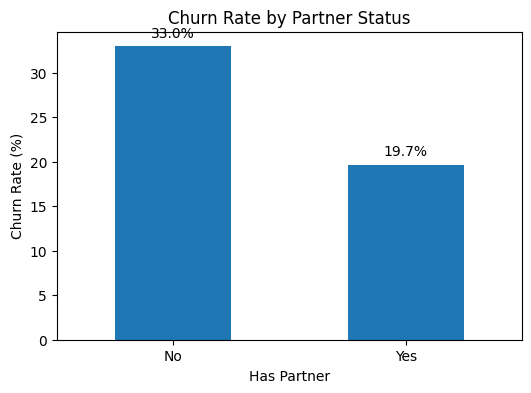

In [7]:
partner_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Has Partner")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

for i, value in enumerate(partner_churn_rate["Yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

In [8]:
highest_group = partner_churn_rate["Yes"].idxmax()
highest_rate = partner_churn_rate["Yes"].max()

print(f"Highest Churn Group : {highest_group}")
print(f"Churn Rate          : {highest_rate:.2f}%")

Highest Churn Group : No
Churn Rate          : 32.96%


In [9]:
difference = (
    partner_churn_rate.loc["No", "Yes"]
    - partner_churn_rate.loc["Yes", "Yes"]
)

print(f"Difference in Churn Rate : {difference:.2f}%")

Difference in Churn Rate : 13.30%


## Business Insight

Customers without a partner exhibit a significantly higher churn rate than customers with a partner.

The analysis shows that customers without a partner have a churn rate of **32.96%**, compared to **19.66%** for customers with a partner. This difference of **13.30 percentage points** suggests that customers with a partner tend to remain with the company for longer periods.

Having a partner may reflect greater household stability or shared service usage, both of which could contribute to improved customer retention.

## Recommendation

Customers without a partner should be considered a higher-risk customer segment.

The business could improve retention by introducing:

- Personalized promotional offers
- Flexible subscription plans
- Loyalty rewards for long-term customers
- Targeted engagement campaigns for single-customer households

These initiatives may help reduce churn among customers who are more likely to discontinue their services.

# Business Question 2.3


Does gender influence customer churn?

Understanding whether customer churn differs across genders helps determine whether retention strategies should be gender-specific or whether the business should focus on other customer characteristics.

This analysis aims to evaluate whether gender has a meaningful relationship with customer churn.

In [10]:
gender_distribution = (
    df["Gender"]
    .value_counts()
    .rename_axis("Gender")
    .reset_index(name="Total Customers")
)

gender_distribution

,Gender,Total Customers
0,Male,3555
1,Female,3488


In [11]:
gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn Label"]
)

gender_churn

Churn Label,No,Yes
Gender,,
Female,2549,939
Male,2625,930


In [12]:
gender_churn_rate = (
    pd.crosstab(
        df["Gender"],
        df["Churn Label"],
        normalize="index"
    ) * 100
).round(2)

gender_churn_rate

Churn Label,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16


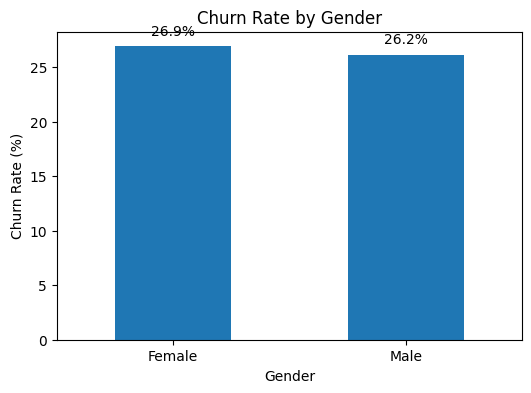

In [13]:
gender_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

for i, value in enumerate(gender_churn_rate["Yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

In [14]:
highest_group = gender_churn_rate["Yes"].idxmax()
highest_rate = gender_churn_rate["Yes"].max()

print(f"Highest Churn Group : {highest_group}")
print(f"Churn Rate          : {highest_rate:.2f}%")

Highest Churn Group : Female
Churn Rate          : 26.92%


In [15]:
difference = abs(
    gender_churn_rate.loc["Male", "Yes"]
    - gender_churn_rate.loc["Female", "Yes"]
)

print(f"Difference in Churn Rate : {difference:.2f}%")

Difference in Churn Rate : 0.76%


## Business Insight

Customer churn is nearly identical across both genders.

Female customers have a churn rate of **26.92%**, while male customers have a churn rate of **26.16%**, resulting in a difference of only **0.76 percentage points**.

This indicates that gender has minimal influence on customer churn and is unlikely to be a primary driver of customer attrition.

## Recommendation

The company should avoid creating gender-specific retention campaigns, as both customer groups exhibit nearly identical churn behavior.

Instead, retention efforts should focus on business factors that have a much stronger relationship with churn, such as contract type, tenure, payment method, pricing, and service usage.

# Business Question 3.1

Does the type of customer contract influence churn?

Contract duration reflects customer commitment and loyalty. Customers with shorter contracts may be more likely to leave the company, while customers with long-term contracts are generally expected to remain with the business.

This analysis aims to identify which contract type experiences the highest churn rate and evaluate whether contract duration is a major driver of customer churn.

In [16]:
contract_distribution = (
    df["Contract"]
    .value_counts()
    .rename_axis("Contract Type")
    .reset_index(name="Total Customers")
)

contract_distribution

,Contract Type,Total Customers
0,Month-to-month,3875
1,Two year,1695
2,One year,1473


In [17]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [18]:
contract_churn_rate = (
    pd.crosstab(
        df["Contract"],
        df["Churn Label"],
        normalize="index"
    ) * 100
).round(2)

contract_churn_rate

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


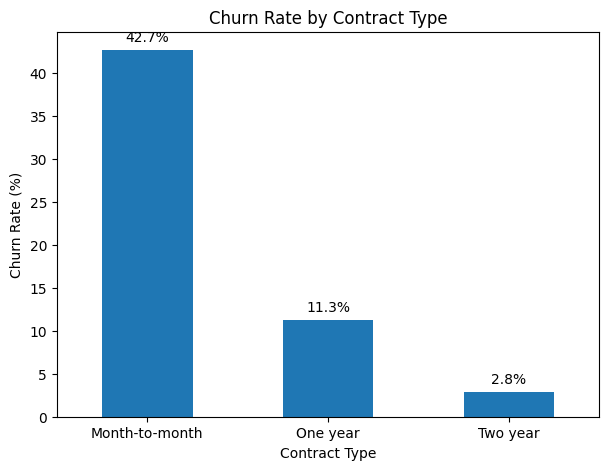

In [19]:
contract_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

for i, value in enumerate(contract_churn_rate["Yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

In [20]:
highest_group = contract_churn_rate["Yes"].idxmax()
highest_rate = contract_churn_rate["Yes"].max()

print(f"Highest Churn Contract : {highest_group}")
print(f"Churn Rate             : {highest_rate:.2f}%")

Highest Churn Contract : Month-to-month
Churn Rate             : 42.71%


In [21]:
difference = (
    contract_churn_rate["Yes"].max()
    - contract_churn_rate["Yes"].min()
)

print(f"Difference in Churn Rate : {difference:.2f}%")

Difference in Churn Rate : 39.88%


## Business Insight

Contract type has a significant impact on customer churn.

Customers with **month-to-month contracts** experience the highest churn rate at **42.71%**, while customers with **two-year contracts** have a churn rate of only **2.83%**.

The difference of **39.88 percentage points** indicates that customers with long-term contracts are substantially more likely to remain with the company.

This suggests that contract duration is one of the strongest predictors of customer retention.

## Recommendation

The company should encourage customers to transition from month-to-month plans to longer-term contracts by offering:

- Discounted annual and two-year plans
- Contract renewal incentives
- Loyalty rewards for long-term commitments
- Limited-time upgrade offers for month-to-month customers

Increasing the adoption of long-term contracts can significantly reduce customer churn and improve customer lifetime value.

# Business Question 3.2

Does the type of internet service influence customer churn?

Different internet services provide varying levels of speed, reliability, and pricing. Understanding whether churn differs across internet service types can help the business identify customer segments that require improved service quality or targeted retention strategies.

This analysis aims to determine which internet service category has the highest churn rate.

In [22]:
internet_distribution = (
    df["Internet Service"]
      .value_counts()
      .rename_axis("Internet Service")
      .reset_index(name="Total Customers")
)

internet_distribution

,Internet Service,Total Customers
0,Fiber optic,3096
1,DSL,2421
2,No,1526


In [23]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"]
)

internet_churn

Churn Label,No,Yes
Internet Service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [24]:
internet_churn_rate = (
    pd.crosstab(
        df["Internet Service"],
        df["Churn Label"],
        normalize="index"
    ) * 100
).round(2)

internet_churn_rate

Churn Label,No,Yes
Internet Service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


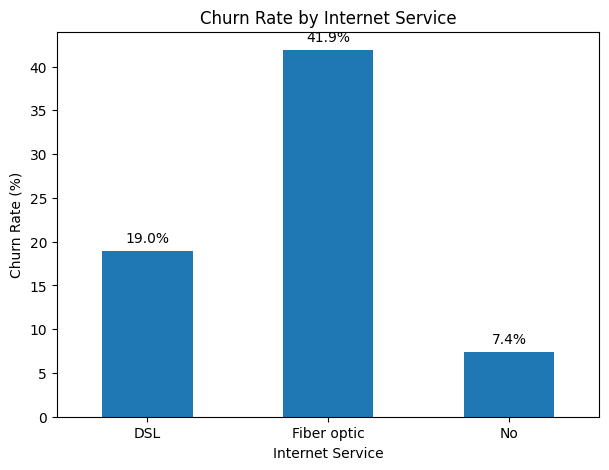

In [25]:
internet_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

for i, value in enumerate(internet_churn_rate["Yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

In [26]:
highest_group = internet_churn_rate["Yes"].idxmax()
highest_rate = internet_churn_rate["Yes"].max()

print(f"Highest Churn Service : {highest_group}")
print(f"Churn Rate            : {highest_rate:.2f}%")

Highest Churn Service : Fiber optic
Churn Rate            : 41.89%


In [27]:
difference = (
    internet_churn_rate["Yes"].max()
    - internet_churn_rate["Yes"].min()
)

print(f"Difference in Churn Rate : {difference:.2f}%")

Difference in Churn Rate : 34.49%


## Business Insight

Internet service type has a significant impact on customer churn.

Customers using **Fiber optic internet** experience the highest churn rate at **41.89%**, while customers without an internet service have the lowest churn rate at **7.40%**.

The **34.49 percentage point** difference suggests that customers subscribed to Fiber optic services are considerably more likely to leave the company.

This finding indicates that internet service type is an important factor influencing customer retention.

## Recommendation

The company should investigate why Fiber optic customers are leaving at a much higher rate.

Potential initiatives include:

- Improving service reliability and customer support
- Reviewing Fiber optic pricing and bundled plans
- Offering loyalty discounts for Fiber optic subscribers
- Conducting customer feedback surveys to identify common pain points

Reducing churn among Fiber optic customers could have a significant impact on overall customer retention.

# Business Question 3.3

Does customer tenure influence churn?

Customer tenure represents how long a customer has been associated with the company. Businesses often expect long-term customers to be more loyal, while newly acquired customers may have a higher risk of leaving.

This analysis aims to determine how churn varies across different customer tenure groups.

In [28]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-36 Months",
        "37-48 Months",
        "49-60 Months",
        "61-72 Months"
    ],
    include_lowest=True
)

df["Tenure Group"].value_counts().sort_index()

Tenure Group
0-12 Months     2186
13-24 Months    1024
25-36 Months     832
37-48 Months     762
49-60 Months     832
61-72 Months    1407
Name: count, dtype: int64

In [29]:
tenure_distribution = (
    df["Tenure Group"]
      .value_counts()
      .sort_index()
      .rename_axis("Tenure Group")
      .reset_index(name="Total Customers")
)

tenure_distribution

,Tenure Group,Total Customers
0,0-12 Months,2186
1,13-24 Months,1024
2,25-36 Months,832
3,37-48 Months,762
4,49-60 Months,832
5,61-72 Months,1407


In [30]:
tenure_churn = pd.crosstab(
    df["Tenure Group"],
    df["Churn Label"]
)

tenure_churn

Churn Label,No,Yes
Tenure Group,,
0-12 Months,1149,1037
13-24 Months,730,294
25-36 Months,652,180
37-48 Months,617,145
49-60 Months,712,120
61-72 Months,1314,93


In [31]:
tenure_churn_rate = (
    pd.crosstab(
        df["Tenure Group"],
        df["Churn Label"],
        normalize="index"
    ) * 100
).round(2)

tenure_churn_rate

Churn Label,No,Yes
Tenure Group,,
0-12 Months,52.56,47.44
13-24 Months,71.29,28.71
25-36 Months,78.37,21.63
37-48 Months,80.97,19.03
49-60 Months,85.58,14.42
61-72 Months,93.39,6.61


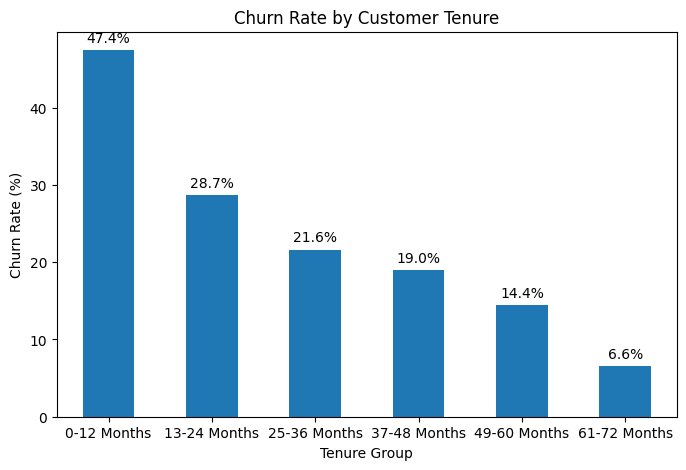

In [32]:
tenure_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

for i, value in enumerate(tenure_churn_rate["Yes"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

In [33]:
highest_group = tenure_churn_rate["Yes"].idxmax()
highest_rate = tenure_churn_rate["Yes"].max()

print(f"Highest Churn Group : {highest_group}")
print(f"Churn Rate          : {highest_rate:.2f}%")

Highest Churn Group : 0-12 Months
Churn Rate          : 47.44%


In [34]:
difference = (
    tenure_churn_rate["Yes"].max()
    - tenure_churn_rate["Yes"].min()
)

print(f"Difference in Churn Rate : {difference:.2f}%")

Difference in Churn Rate : 40.83%


## Business Insight

Customer tenure has a significant impact on customer churn.

Customers within their **first year (0–12 months)** have the highest churn rate at **47.44%**, whereas customers who have remained with the company for **61–72 months** have a churn rate of only **6.61%**.

The **40.83 percentage point** difference indicates that long-term customers are substantially more loyal, while newly acquired customers face the highest risk of leaving.

This highlights customer tenure as one of the strongest indicators of customer retention.

## Recommendation

The company should prioritize retaining customers during their first year by implementing:

- Welcome and onboarding programs
- Proactive customer engagement during the initial months
- Personalized retention offers before contract renewal
- Early customer satisfaction surveys
- Loyalty rewards for customers reaching key tenure milestones

Improving the early customer experience can significantly reduce churn and increase long-term customer retention.

# Business Question 4.1

Do customers with higher monthly charges churn more frequently?

Monthly charges directly affect customer affordability and perceived value. Customers paying higher monthly fees may be more likely to discontinue their services if they believe they are not receiving sufficient value.

This analysis aims to compare the monthly charges of churned and retained customers to determine whether pricing influences customer churn.

In [35]:
monthly_summary = (
    df.groupby("Churn Label")["Monthly Charges"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

monthly_summary

,count,mean,median,min,max
Churn Label,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


<Figure size 700x500 with 0 Axes>

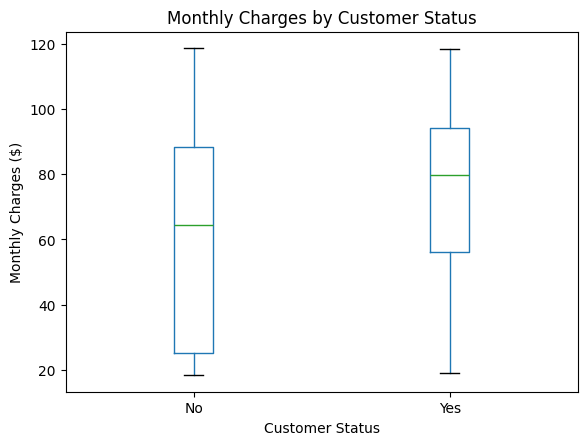

In [36]:
plt.figure(figsize=(7,5))

df.boxplot(
    column="Monthly Charges",
    by="Churn Label",
    grid=False
)

plt.title("Monthly Charges by Customer Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges ($)")

plt.show()

In [37]:
avg_monthly = (
    df.groupby("Churn Label")["Monthly Charges"]
      .mean()
      .round(2)
)

avg_monthly

Churn Label
No     61.27
Yes    74.44
Name: Monthly Charges, dtype: float64

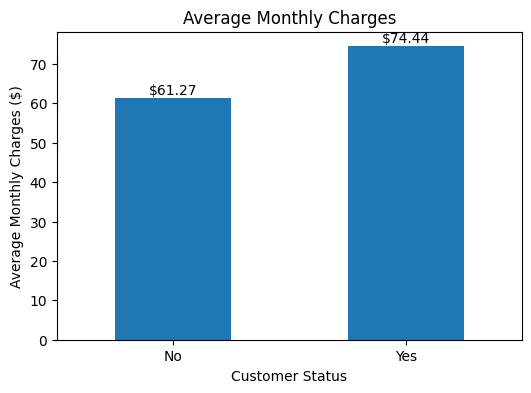

In [38]:
avg_monthly.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Monthly Charges")
plt.xlabel("Customer Status")
plt.ylabel("Average Monthly Charges ($)")

plt.xticks(rotation=0)

for i, value in enumerate(avg_monthly):
    plt.text(i, value + 1, f"${value:.2f}", ha="center")

plt.show()

In [39]:
difference = (
    avg_monthly["Yes"]
    - avg_monthly["No"]
)

print(f"Difference in Average Monthly Charges : ${difference:.2f}")

Difference in Average Monthly Charges : $13.17


## Business Insight

Monthly charges show a clear relationship with customer churn.

Customers who churned pay an average monthly charge of **$74.44**, compared to **$61.27** for customers who remained with the company.

The difference of **$13.17 per month** suggests that customers paying higher monthly fees are more likely to discontinue their services.

This indicates that pricing and perceived value play an important role in customer retention.

## Recommendation

The company should review pricing strategies for customers with high monthly charges.

Possible initiatives include:

- Personalized discounts for high-value customers
- Bundled service packages that improve perceived value
- Loyalty rewards for long-term premium customers
- Targeted promotional offers before contract renewal

These strategies can help reduce churn among customers with higher monthly subscription costs.

# Business Question 4.2

Does the Payment Method influence customer churn?

Business Insight

Customers using **Electronic Check** exhibit the highest churn rate at **45.29%**, while customers using **Credit Card (Automatic)** have the lowest churn rate at **15.24%**.

The difference between the highest and lowest churn rates is **30.05%**, indicating that payment method has a significant influence on customer retention.

Automatic payment methods (Credit Card and Bank Transfer) are associated with considerably lower churn compared to Electronic Check.


In [40]:
payment_distribution = (
    df["Payment Method"]
    .value_counts()
    .rename_axis("Payment Method")
    .reset_index(name="Total Customers")
)

payment_distribution

,Payment Method,Total Customers
0,Electronic check,2365
1,Mailed check,1612
2,Bank transfer (automatic),1544
3,Credit card (automatic),1522


In [41]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"]
)

payment_churn

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [42]:
payment_churn_rate = (
    pd.crosstab(
        df["Payment Method"],
        df["Churn Label"],
        normalize="index"
    )
    * 100
).round(2)

payment_churn_rate

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


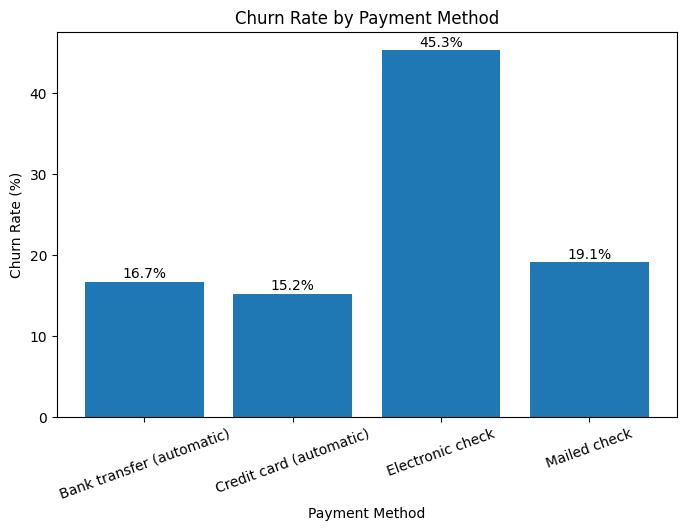

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    payment_churn_rate.index,
    payment_churn_rate["Yes"]
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center"
    )

plt.show()

In [44]:
highest_group = payment_churn_rate["Yes"].idxmax()
highest_rate = payment_churn_rate["Yes"].max()

print(f"Highest Churn Payment Method : {highest_group}")
print(f"Churn Rate                  : {highest_rate:.2f}%")

Highest Churn Payment Method : Electronic check
Churn Rate                  : 45.29%


In [45]:
difference = (
    payment_churn_rate["Yes"].max()
    - payment_churn_rate["Yes"].min()
)

print(f"Difference in Churn Rate : {difference:.2f}%")

Difference in Churn Rate : 30.05%


### Business Insight

Customers using **Electronic Check** exhibit the highest churn rate at **45.29%**, while customers using **Credit Card (Automatic)** have the lowest churn rate at **15.24%**.

The difference between the highest and lowest churn rates is **30.05%**, indicating that payment method has a significant influence on customer retention.

Automatic payment methods (Credit Card and Bank Transfer) are associated with considerably lower churn compared to Electronic Check.


### Recommendation

The company should encourage customers to switch from **Electronic Check** to **Automatic Payment Methods** by offering incentives such as cashback, discounts, or simplified auto-payment enrollment.

Reducing dependency on Electronic Check payments may improve customer retention and decrease customer churn.

# Business Question 4.3
Does Paperless Billing influence customer churn?

Objective

Analyze whether customers using Paperless Billing are more likely to churn compared to customers receiving traditional paper bills. The objective is to determine if billing preference is associated with customer retention.

In [46]:
paperless_distribution = (
    df["Paperless Billing"]
    .value_counts()
    .rename_axis("Paperless Billing")
    .reset_index(name="Total Customers")
)

paperless_distribution

,Paperless Billing,Total Customers
0,Yes,4171
1,No,2872


In [47]:
paperless_churn = pd.crosstab(
    df["Paperless Billing"],
    df["Churn Label"]
)

paperless_churn

Churn Label,No,Yes
Paperless Billing,,
No,2403,469
Yes,2771,1400


In [48]:
paperless_churn_rate = (
    pd.crosstab(
        df["Paperless Billing"],
        df["Churn Label"],
        normalize="index"
    )
    * 100
).round(2)

paperless_churn_rate

Churn Label,No,Yes
Paperless Billing,,
No,83.67,16.33
Yes,66.43,33.57


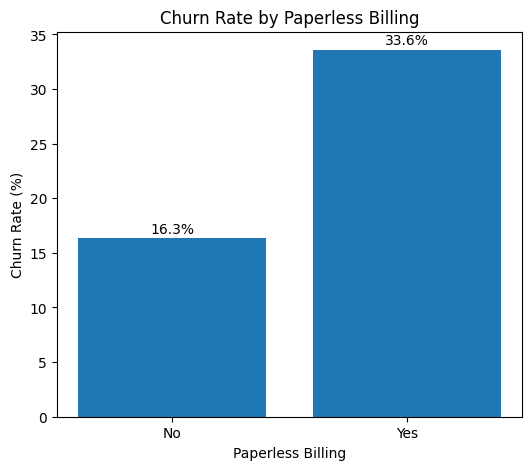

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

bars = plt.bar(
    paperless_churn_rate.index,
    paperless_churn_rate["Yes"]
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center"
    )

plt.show()

In [50]:
highest_group = paperless_churn_rate["Yes"].idxmax()
highest_rate = paperless_churn_rate["Yes"].max()

print(f"Highest Churn Group : {highest_group}")
print(f"Churn Rate          : {highest_rate:.2f}%")

Highest Churn Group : Yes
Churn Rate          : 33.57%


In [51]:
difference = (
    paperless_churn_rate["Yes"].max()
    - paperless_churn_rate["Yes"].min()
)

print(f"Difference in Churn Rate : {difference:.2f}%")

Difference in Churn Rate : 17.24%


### Business Insight

Customers using **Paperless Billing** exhibit the highest churn rate at **33.57%**, while customers who do not use Paperless Billing have a churn rate of **16.33%**.

The difference between the two customer groups is **17.24%**, indicating that billing preference has a noticeable relationship with customer churn.


### Recommendation

The company should closely monitor customers using **Paperless Billing**, especially those with other high-risk characteristics such as **Month-to-Month contracts**, **Fiber Optic Internet**, and **high monthly charges**.

Targeted retention campaigns and personalized engagement should be prioritized for this customer segment to reduce customer churn.

# Business Question 5

## Which combination of customer characteristics represents the highest-risk customer profile?

### Objective

The previous analyses identified individual factors associated with customer churn, such as contract type, internet service, tenure, payment method, and billing preference.

In this analysis, we combine these factors to identify the customer profiles that are most likely to churn. This helps the business understand which groups require immediate retention efforts and supports data-driven decision-making for customer retention strategies.

In [59]:
profile_summary = (
    df.groupby([
        "Contract",
        "Internet Service",
        "Tenure Group"
    ])
    .agg(
        Total_Customers=("Churn Label","count"),
        Churned_Customers=("Churn Value","sum")
    )
)

profile_summary["Churn Rate"] = (
    profile_summary["Churned_Customers"]
    / profile_summary["Total_Customers"]
    *100
).round(2)

profile_summary = (
    profile_summary
    .reset_index()
)

profile_summary

,Contract,Internet Service,Tenure Group,Total_Customers,Churned_Customers,Churn Rate
0,Month-to-month,DSL,0-12 Months,690,293,42.46
1,Month-to-month,DSL,13-24 Months,232,55,23.71
2,Month-to-month,DSL,25-36 Months,137,17,12.41
3,Month-to-month,DSL,37-48 Months,90,19,21.11
4,Month-to-month,DSL,49-60 Months,59,10,16.95
...,...,...,...,...,...,...
48,Two year,No,13-24 Months,64,0,0.00
49,Two year,No,25-36 Months,61,2,3.28
50,Two year,No,37-48 Months,99,0,0.00
51,Two year,No,49-60 Months,116,3,2.59


In [60]:
profile_summary = profile_summary[
    profile_summary["Total_Customers"] >= 50
]

profile_summary

,Contract,Internet Service,Tenure Group,Total_Customers,Churned_Customers,Churn Rate
0,Month-to-month,DSL,0-12 Months,690,293,42.46
1,Month-to-month,DSL,13-24 Months,232,55,23.71
2,Month-to-month,DSL,25-36 Months,137,17,12.41
3,Month-to-month,DSL,37-48 Months,90,19,21.11
4,Month-to-month,DSL,49-60 Months,59,10,16.95
...,...,...,...,...,...,...
48,Two year,No,13-24 Months,64,0,0.00
49,Two year,No,25-36 Months,61,2,3.28
50,Two year,No,37-48 Months,99,0,0.00
51,Two year,No,49-60 Months,116,3,2.59


In [61]:
profile_summary = (
    profile_summary
    .sort_values(
        by="Churn Rate",
        ascending=False
    )
)

profile_summary.head(10)

,Contract,Internet Service,Tenure Group,Total_Customers,Churned_Customers,Churn Rate
6,Month-to-month,Fiber optic,0-12 Months,916,643,70.20
7,Month-to-month,Fiber optic,13-24 Months,425,215,50.59
8,Month-to-month,Fiber optic,25-36 Months,309,139,44.98
0,Month-to-month,DSL,0-12 Months,690,293,42.46
9,Month-to-month,Fiber optic,37-48 Months,212,87,41.04
10,Month-to-month,Fiber optic,49-60 Months,174,55,31.61
11,Month-to-month,Fiber optic,61-72 Months,92,23,25.00
1,Month-to-month,DSL,13-24 Months,232,55,23.71
12,Month-to-month,No,0-12 Months,388,88,22.68
28,One year,Fiber optic,49-60 Months,155,33,21.29


## Business Insight

- The highest churn rate (**70.20%**) is observed among customers with **Month-to-month contracts**, **Fiber optic Internet Service**, and **0–12 Months tenure**.
- Customers on Month-to-month contracts consistently show higher churn compared to customers with long-term contracts.
- New Fiber optic customers are significantly more likely to leave during their first year of service.
- Customers with One-year and Two-year contracts show considerably lower churn rates, indicating better customer retention.

---

## Business Recommendation

- Focus retention campaigns on customers with **Month-to-month contracts** during their **first 12 months**.
- Offer attractive discounts or loyalty benefits to encourage customers to switch from Month-to-month to long-term contracts.
- Improve onboarding experience and customer support for new Fiber optic customers.
- Implement an early warning system to identify customers matching this high-risk profile and proactively engage them before they churn.